In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# 🧠 Brain Tumor Detection using Deep Learning

## Transfer Learning with EfficientNetB0

### 🎯 Project Goal

Develop an AI-powered Brain Tumor Detection System capable of classifying MRI scans into:

- Glioma
- Meningioma
- Pituitary Tumor
- No Tumor

---

## 🚀 Technologies Used

- TensorFlow 2.x
- EfficientNetB0
- Transfer Learning
- Python
- NumPy
- Matplotlib
- Scikit-learn

---

## 📌 Workflow

1. Data Preparation
2. Data Augmentation
3. Build EfficientNetB0 Model
4. Train Model
5. Fine-Tune Model
6. Evaluate Performance
7. Save Best Model
8. Verify Saved Model
9. Deploy with Streamlit
10. Integrate AI Medical Assistant

SyntaxError: invalid syntax (3518674897.py, line 7)

In [81]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import Model

from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

In [74]:
print("="*50)
print("TensorFlow Version :", tf.__version__)
print("="*50)

TensorFlow Version : 2.20.0


In [82]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("✅ GPU Detected")
    print(gpus)
else:
    print("❌ GPU Not Found")

✅ GPU Detected
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [83]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random Seed:", SEED)

Random Seed: 42


In [93]:
IMG_HEIGHT = 224
IMG_WIDTH = 224

IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 32

INITIAL_EPOCHS = 15

FINE_TUNE_EPOCHS = 10

LEARNING_RATE = 1e-3

FINE_TUNE_LR = 1e-5

NUM_CLASSES = 4

AUTOTUNE = tf.data.AUTOTUNE

In [95]:
DATASET_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "Training")
TEST_DIR = os.path.join(DATASET_PATH, "Testing")

In [96]:
print("Training Exists :", os.path.exists(TRAIN_DIR))
print("Testing Exists :", os.path.exists(TEST_DIR))

Training Exists : True
Testing Exists : True


In [97]:
print("Training Classes")

for folder in sorted(os.listdir(TRAIN_DIR)):
    print("•", folder)

print("\nTesting Classes")

for folder in sorted(os.listdir(TEST_DIR)):
    print("•", folder)

Training Classes
• glioma
• meningioma
• notumor
• pituitary

Testing Classes
• glioma
• meningioma
• notumor
• pituitary


In [98]:
print("Training Images\n")

for folder in sorted(os.listdir(TRAIN_DIR)):
    count = len(os.listdir(os.path.join(TRAIN_DIR, folder)))
    print(f"{folder:<12} : {count}")

print("\nTesting Images\n")

for folder in sorted(os.listdir(TEST_DIR)):
    count = len(os.listdir(os.path.join(TEST_DIR, folder)))
    print(f"{folder:<12} : {count}")

Training Images

glioma       : 1400
meningioma   : 1400
notumor      : 1400
pituitary    : 1400

Testing Images

glioma       : 400
meningioma   : 400
notumor      : 400
pituitary    : 400


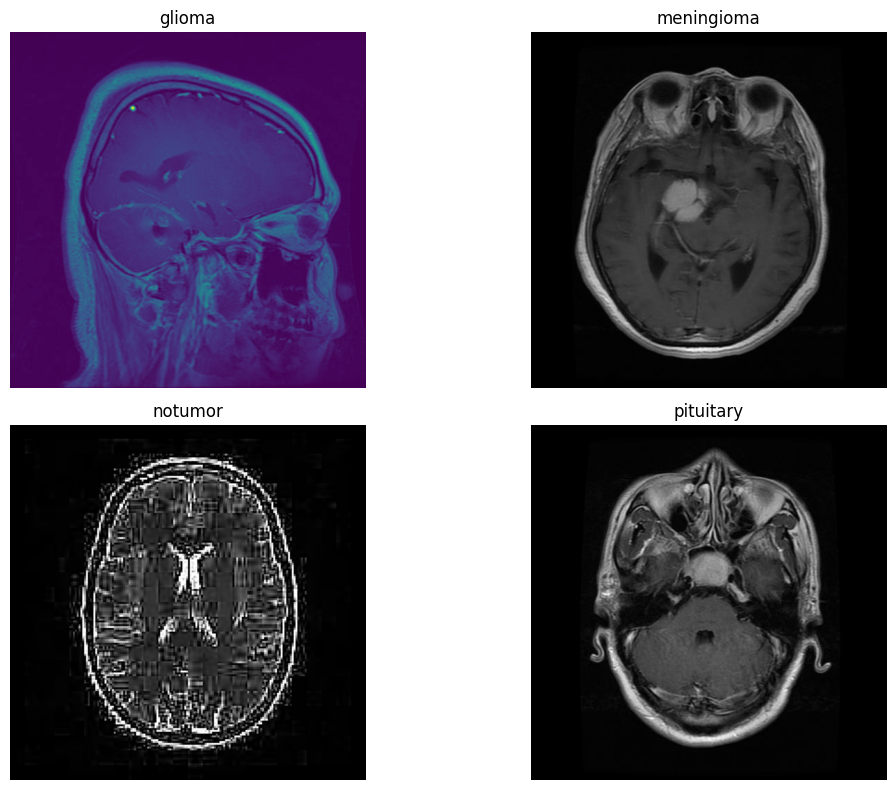

In [99]:
plt.figure(figsize=(12, 8))

classes = sorted(os.listdir(TRAIN_DIR))

for i, class_name in enumerate(classes):

    image_path = os.path.join(
        TRAIN_DIR,
        class_name,
        os.listdir(os.path.join(TRAIN_DIR, class_name))[0]
    )

    img = plt.imread(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [100]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.


In [103]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


In [104]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 1600 files belonging to 4 classes.


In [105]:
print("Training Dataset")
print(train_ds)

print("\nValidation Dataset")
print(val_ds)

print("\nTesting Dataset")
print(test_ds)

Training Dataset
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

Validation Dataset
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

Testing Dataset
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>


In [106]:
CLASS_NAMES = train_ds.class_names

print("Class Names:")
print(CLASS_NAMES)

print("\nNumber of Classes:", len(CLASS_NAMES))

Class Names:
['glioma', 'meningioma', 'notumor', 'pituitary']

Number of Classes: 4


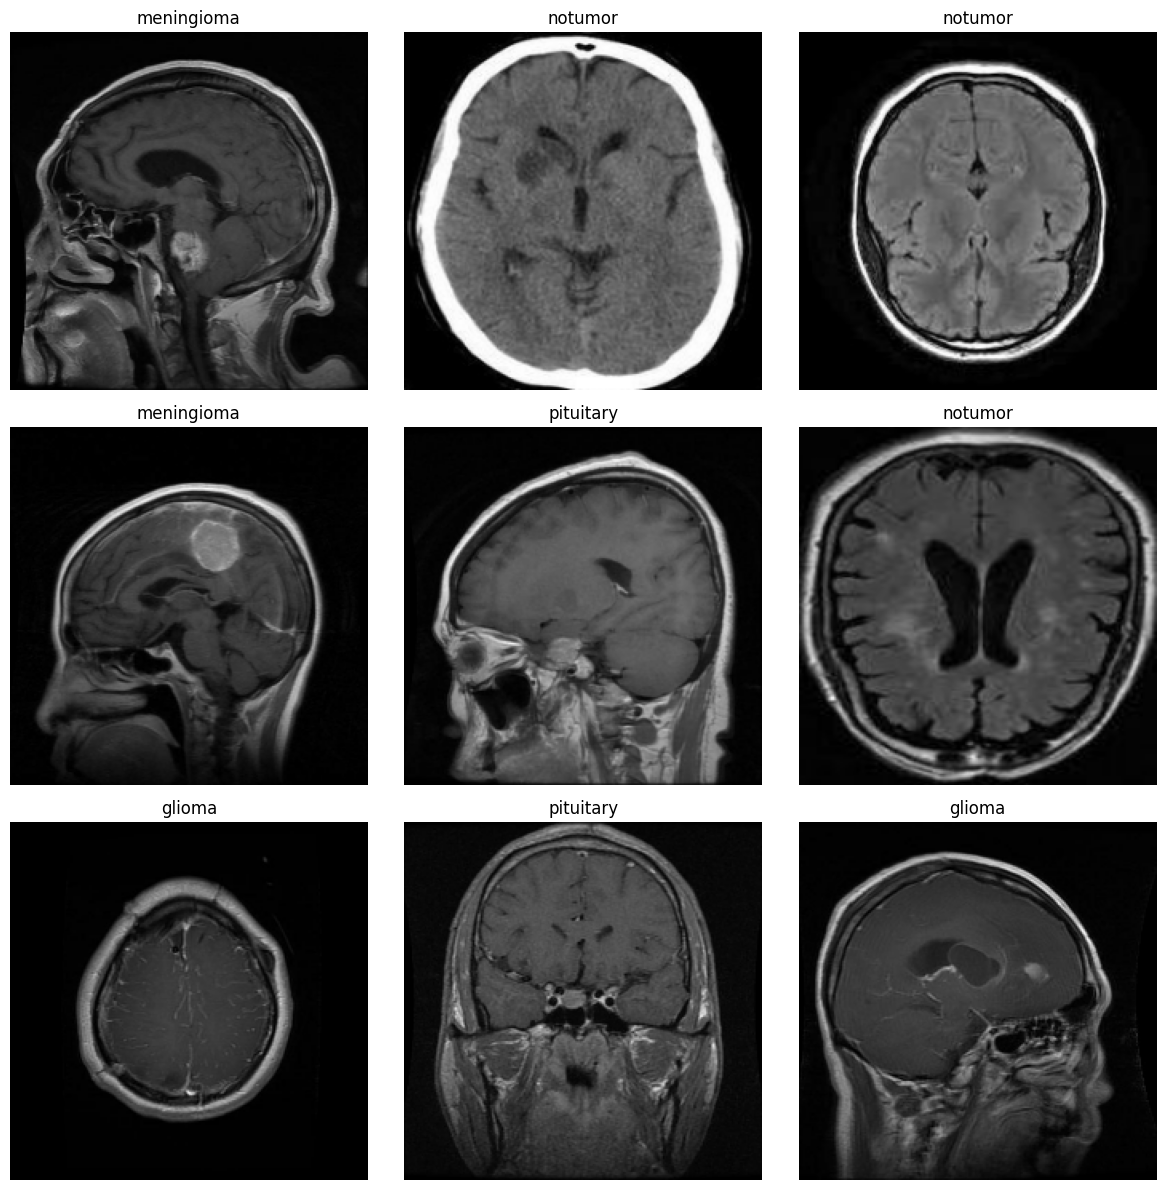

In [107]:
plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(CLASS_NAMES[np.argmax(labels[i])])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [109]:
train_ds = train_ds.cache().prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

test_ds = test_ds.prefetch(AUTOTUNE)

In [110]:
for images, labels in train_ds.take(1):

    print("Images Shape :", images.shape)

    print("Labels Shape :", labels.shape)

    break

Images Shape : (32, 224, 224, 3)
Labels Shape : (32, 4)


In [111]:
print("Training Batches   :", tf.data.experimental.cardinality(train_ds).numpy())

print("Validation Batches :", tf.data.experimental.cardinality(val_ds).numpy())

print("Testing Batches    :", tf.data.experimental.cardinality(test_ds).numpy())

Training Batches   : 140
Validation Batches : 35
Testing Batches    : 50


In [113]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

In [115]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [123]:
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.30)(x)

x = layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(0.001)
)(x)

x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

In [124]:
model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [126]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [129]:
checkpoint = ModelCheckpoint(
    filepath="brain_tumor_best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    checkpoint,
    early_stop,
    reduce_lr
]

In [130]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15


E0000 00:00:1785308178.532676      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_17_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7070 - loss: 1.3230 - precision: 0.7196 - recall: 0.6795
Epoch 1: val_accuracy improved from None to 0.81786, saving model to brain_tumor_best_model.keras

Epoch 1: finished saving model to brain_tumor_best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 130ms/step - accuracy: 0.7654 - loss: 1.1462 - precision: 0.7768 - recall: 0.7504 - val_accuracy: 0.8179 - val_loss: 0.8650 - val_precision: 0.8559 - val_recall: 0.7795 - learning_rate: 0.0010
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8328 - loss: 0.9107 - precision: 0.8439 - recall: 0.8238
Epoch 2: val_accuracy improved from 0.81786 to 0.86071, saving model to brain_tumor_best_model.keras

Epoch 2: finished saving model to brain_tumor_best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - accuracy: 0.8400 - loss: 0.8744 - precision: 0.8516 - recall: 0.8313 - val_accuracy: 0.8607 - val_loss: 0.7448 - val_precision: 0.8804 - val_recall: 0.8411 - learnin

In [132]:
model.save("brain_tumor_ai_final.keras")

print("✅ Model saved successfully.")

✅ Model saved successfully.


In [133]:
saved_model = tf.keras.models.load_model(
    "brain_tumor_ai_final.keras"
)

print("✅ Model loaded successfully.")

✅ Model loaded successfully.


In [134]:
saved_model.evaluate(test_ds)

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.8825 - loss: 0.6692 - precision: 0.8931 - recall: 0.8769


[0.6692308783531189,
 0.8824999928474426,
 0.8930617570877075,
 0.8768749833106995]

In [135]:
base_model.trainable = True

# Freeze the first 200 layers
for layer in base_model.layers[:200]:
    layer.trainable = False

print("Trainable layers:")
print(sum(layer.trainable for layer in base_model.layers))

Trainable layers:
38


In [137]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

In [138]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10


E0000 00:00:1785308767.477588      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_17_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7810 - loss: 0.7857 - precision: 0.7991 - recall: 0.7507
Epoch 1: val_accuracy did not improve from 0.92232
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 124ms/step - accuracy: 0.8018 - loss: 0.7341 - precision: 0.8209 - recall: 0.7746 - val_accuracy: 0.9089 - val_loss: 0.4687 - val_precision: 0.9182 - val_recall: 0.9018 - learning_rate: 1.0000e-05
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8419 - loss: 0.6430 - precision: 0.8586 - recall: 0.8268
Epoch 2: val_accuracy did not improve from 0.92232

Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.8542 - loss: 0.6226 - precision: 0.8716 - recall: 0.8411 - val_accuracy: 0.9027 - val_loss: 0.4737 - val_precision: 0.9115 - val_recall: 0.8920 - learning_rate: 1.0000e-05
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8625 - loss: 0.5909 - precision: 0.8775 - recall: 0.8477

In [139]:
best_model = tf.keras.models.load_model("brain_tumor_best_model.keras")

print("✅ Best model loaded successfully.")

✅ Best model loaded successfully.


In [144]:
test_loss, test_accuracy, test_precision, test_recall = best_model.evaluate(
    test_ds,
    verbose=1
)

print("\n" + "=" * 50)
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test Loss     : {test_loss:.4f}")
print("=" * 50)

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.8825 - loss: 0.6692 - precision: 0.8931 - recall: 0.8769

Test Accuracy : 0.8825
Test Precision: 0.8931
Test Recall   : 0.8769
Test Loss     : 0.6692


In [146]:
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = best_model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Prediction completed successfully.")

Prediction completed successfully.


In [147]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
)

              precision    recall  f1-score   support

      glioma     0.8829    0.7350    0.8022       400
  meningioma     0.8317    0.8275    0.8296       400
     notumor     0.8884    0.9950    0.9387       400
   pituitary     0.9240    0.9725    0.9476       400

    accuracy                         0.8825      1600
   macro avg     0.8817    0.8825    0.8795      1600
weighted avg     0.8817    0.8825    0.8795      1600



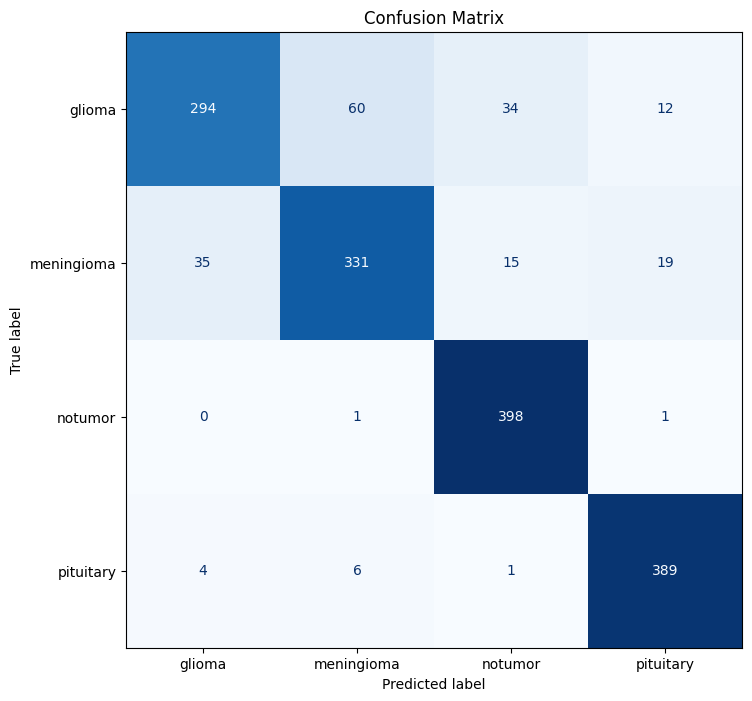

In [148]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")

plt.show()

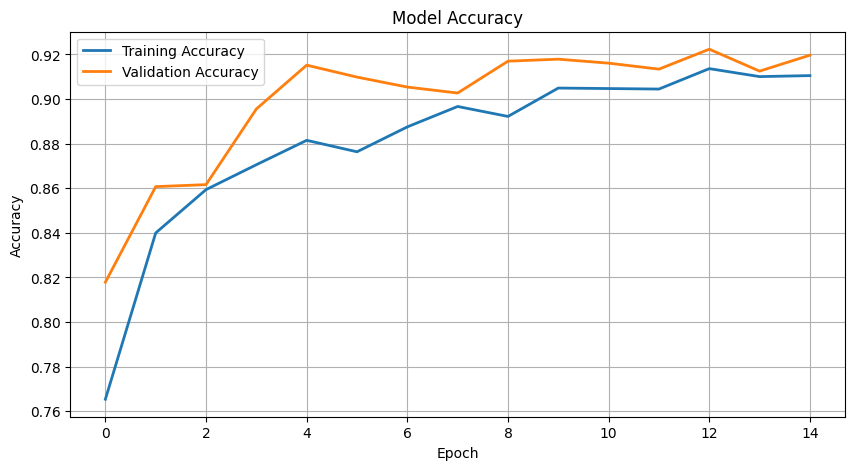

In [150]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

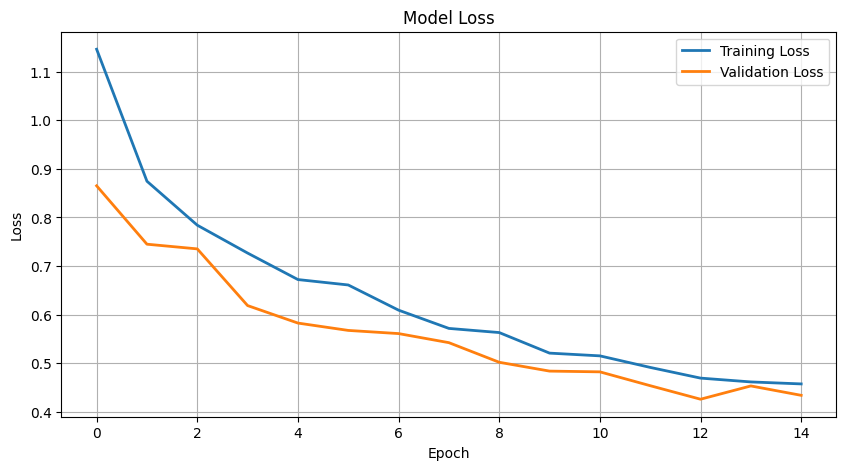

In [151]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [153]:
best_model.save("brain_tumor_final_deployment.keras")

print("✅ Final deployment model saved.")

✅ Final deployment model saved.


In [155]:
deployment_model = tf.keras.models.load_model(
    "brain_tumor_final_deployment.keras"
)

print("✅ Deployment model verified successfully.")

✅ Deployment model verified successfully.


In [157]:
print("=" * 50)
print("Brain Tumor Detection Model")
print("=" * 50)

print("Architecture : EfficientNetB0")
print("Classes      :", CLASS_NAMES)
print("Image Size   :", IMG_SIZE)
print("Batch Size   :", BATCH_SIZE)

print("\nFinal Test Accuracy : {:.2f}%".format(test_accuracy * 100))
print("Final Precision     : {:.2f}%".format(test_precision * 100))
print("Final Recall        : {:.2f}%".format(test_recall * 100))

print("=" * 50)

Brain Tumor Detection Model
Architecture : EfficientNetB0
Classes      : ['glioma', 'meningioma', 'notumor', 'pituitary']
Image Size   : (224, 224)
Batch Size   : 32

Final Test Accuracy : 88.25%
Final Precision     : 89.31%
Final Recall        : 87.69%


In [167]:
import random
from PIL import Image

In [169]:
# Select a random class
random_class = random.choice(CLASS_NAMES)

# Folder path
class_folder = os.path.join(TEST_DIR, random_class)

# Random image
image_name = random.choice(os.listdir(class_folder))

image_path = os.path.join(class_folder, image_name)

print("Image Path:")
print(image_path)

print("\nActual Class:")
print(random_class)

Image Path:
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/meningioma/Te-aug-me_20.jpg

Actual Class:
meningioma


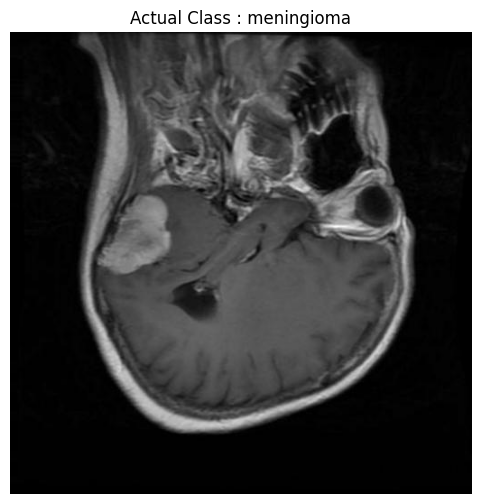

In [170]:
image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title(f"Actual Class : {random_class}")
plt.axis("off")
plt.show()

In [176]:
img = image.resize(IMG_SIZE)

img_array = np.array(img, dtype=np.float32)

# IMPORTANT:
# Do NOT divide by 255 here because the model was trained
# with image_dataset_from_directory() pixel values.

img_array = np.expand_dims(img_array, axis=0)

In [177]:
prediction = best_model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction)

predicted_class = CLASS_NAMES[predicted_index]

confidence = prediction[0][predicted_index] * 100

print("="*50)
print("Actual Class    :", random_class)
print("Predicted Class :", predicted_class)
print("Confidence      : {:.2f}%".format(confidence))
print("="*50)

Actual Class    : meningioma
Predicted Class : meningioma
Confidence      : 97.11%


In [178]:
for i, class_name in enumerate(CLASS_NAMES):
    print(f"{class_name:<12}: {prediction[0][i]*100:.2f}%")

glioma      : 2.86%
meningioma  : 97.11%
notumor     : 0.00%
pituitary   : 0.03%


In [179]:
for i in range(10):

    random_class = random.choice(CLASS_NAMES)

    class_folder = os.path.join(TEST_DIR, random_class)

    image_name = random.choice(os.listdir(class_folder))

    image_path = os.path.join(class_folder, image_name)

    image = Image.open(image_path).convert("RGB")

    img = image.resize(IMG_SIZE)

    img_array = np.array(img, dtype=np.float32)

    # Keep preprocessing consistent with Cell 47
    img_array = np.expand_dims(img_array, axis=0)

    prediction = best_model.predict(img_array, verbose=0)

    predicted = CLASS_NAMES[np.argmax(prediction)]

    confidence = np.max(prediction) * 100

    print(f"{i+1}. Actual: {random_class:<12} | Predicted: {predicted:<12} | Confidence: {confidence:.2f}%")

1. Actual: glioma       | Predicted: glioma       | Confidence: 99.96%
2. Actual: glioma       | Predicted: glioma       | Confidence: 96.14%
3. Actual: meningioma   | Predicted: meningioma   | Confidence: 95.09%
4. Actual: pituitary    | Predicted: pituitary    | Confidence: 99.72%
5. Actual: notumor      | Predicted: notumor      | Confidence: 99.99%
6. Actual: meningioma   | Predicted: meningioma   | Confidence: 99.96%
7. Actual: meningioma   | Predicted: meningioma   | Confidence: 70.85%
8. Actual: notumor      | Predicted: notumor      | Confidence: 98.75%
9. Actual: glioma       | Predicted: glioma       | Confidence: 99.99%
10. Actual: notumor      | Predicted: notumor      | Confidence: 100.00%


In [181]:
model_path="brain_tumor_ai_final.keras"
size_bytes=os.path.getsize(model_path)
size_mb=size_bytes / (1024 * 1024)
print(f"Model Size: {size_mb: .2f} mb")


Model Size:  20.08 mb


In [182]:
import os

MODEL_PATH = "brain_tumor_ai_final.keras"

if os.path.exists(MODEL_PATH):
    print("✅ Model found!")
    print(f"Path: {os.path.abspath(MODEL_PATH)}")
    print(f"Size: {os.path.getsize(MODEL_PATH) / (1024 * 1024):.2f} MB")
else:
    print("❌ Model not found!")

✅ Model found!
Path: /kaggle/working/brain_tumor_ai_final.keras
Size: 20.08 MB


In [183]:
from IPython.display import FileLink

FileLink("brain_tumor_ai_final.keras")

/kaggle/working/brain_tumor_ai_final.keras